In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv('../data/weather_classification_data.csv')
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [7]:
print("Ukuran Data Train:", X_train.shape)
print("Ukuran Data Test:", X_test.shape)

# Output yang terlihat:
# Ukuran Data Train: (10560, 18)
# Ukuran Data Test: (2640, 18)

# Model KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Output yang terlihat (saat kursor di atasnya):
# KNeighborsClassifier()

# prediksi
y_pred = knn.predict(X_test)

# evaluasi
from sklearn.metrics import classification_report
print("====== CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

# Output Classification Report:
#              precision    recall  f1-score   support
#
#     Cloudy       0.86      0.88      0.87       653
#      Rainy       0.87      0.89      0.88       647
#      Snowy       0.94      0.94      0.94       701
#      Sunny       0.92      0.87      0.90       641

Ukuran Data Train: (10560, 18)
Ukuran Data Test: (2640, 18)
====== CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Cloudy       0.86      0.88      0.87       651
       Rainy       0.87      0.89      0.88       647
       Snowy       0.94      0.94      0.94       701
       Sunny       0.92      0.87      0.90       641

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640




====== CONFUSION MATRIX ======
[[573  45  12  21]
 [ 37 579  18  13]
 [ 14  17 658  12]
 [ 42  27  15 557]]


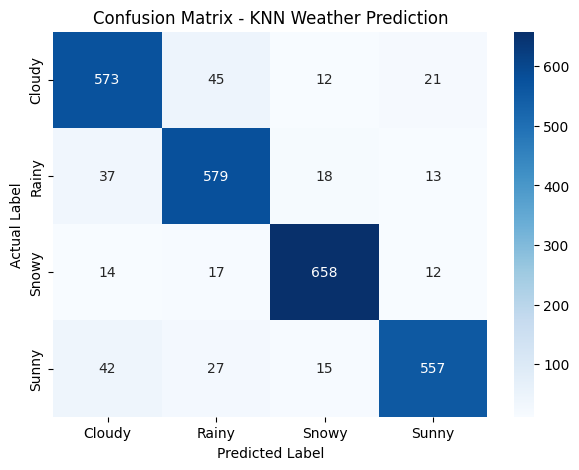

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
print("\n====== CONFUSION MATRIX ======")
print(cm)

# Output yang terlihat:
# CONFUSION MATRIX
# [[573  45  12  21]
#  [ 37 579  18  13]
#  [ 14  17 658  12]
#  [ 42  27  15 557]]

# Visualisasi Confusion Matrix
# Asumsi 'knn.classes_' adalah nama-nama kelas cuaca (Cloudy, Rainy, Snowy, Sunny)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_,
            yticklabels=knn.classes_)
plt.title("Confusion Matrix - KNN Weather Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [9]:
# Contoh Prediksi Data Baru
import pandas as pd

sample = pd.DataFrame({
    "Temperature": [20],
    "Humidity": [70],
    "Wind Speed": [5],
    "Precipitation (%)": [40],
    "Cloud Cover": ["overcast"],
    "Atmospheric Pressure": [1010],
    "UV Index": [3],
    "Season": ["Winter"],
    "Visibility (km)": [5],
    "Location": ["inland"]
})

# Asumsi 'preprocessor' sudah didefinisikan dan 'knn' sudah dilatih dari langkah sebelumnya
sample_processed = preprocessor.transform(sample)
predicted_weather = knn.predict(sample_processed)

print("\nPrediksi Cuaca untuk Data Baru:", predicted_weather[0])

# Output yang terlihat:
# Prediksi Cuaca untuk Data Baru: Cloudy


Prediksi Cuaca untuk Data Baru: Cloudy
